<a href="https://colab.research.google.com/github/useDeep/learn_pytorch/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
torch.__version__


'2.8.0+cu126'

## 1. Data (preparing and loading)

In [2]:
# Create data using the linear regression formula
# parameters:
weight= 0.7
bias= 0.3

start= 0
end= 1
step= 0.02
X= torch.arange(start, end, step).unsqueeze(dim= 1)
y= weight * X + bias
y

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [0.5100],
        [0.5240],
        [0.5380],
        [0.5520],
        [0.5660],
        [0.5800],
        [0.5940],
        [0.6080],
        [0.6220],
        [0.6360],
        [0.6500],
        [0.6640],
        [0.6780],
        [0.6920],
        [0.7060],
        [0.7200],
        [0.7340],
        [0.7480],
        [0.7620],
        [0.7760],
        [0.7900],
        [0.8040],
        [0.8180],
        [0.8320],
        [0.8460],
        [0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

## Splitting data into training and test data

In [3]:
train_split= int(0.8* len(X))

X_train, y_train= X[: train_split], y[: train_split]
X_test, y_test= X[train_split: ], y[train_split: ]

len(X_train), len(X_test)

(40, 10)

In [4]:
def plot_graph(X_train= X_train, y_train= y_train, X_test= X_test, y_test= y_test, predictions= None):
  plt.scatter(X_train, y_train, c='r', label="Training data")
  plt.scatter(X_test, y_test, c='g', label= "Test data")

  if predictions is not None:
    plt.scatter(X_test, predictions, c='b', label= "Predictions")

  plt.legend()

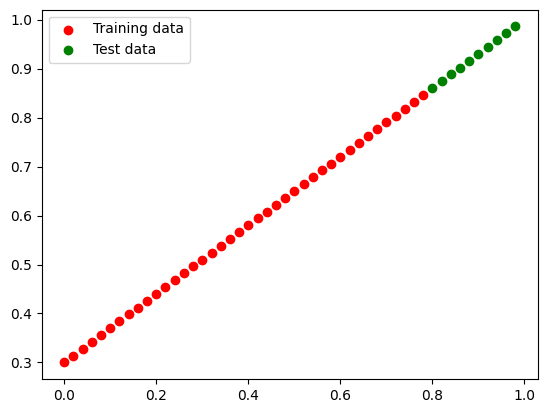

In [5]:
plot_graph(X_train, y_train, X_test, y_test)

## Building model

In [6]:
# Linear regression model

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights= nn.Parameter(torch.randn(1, requires_grad= True, dtype= torch.float))
    self.bias= nn.Parameter(torch.randn(1, requires_grad= True, dtype=torch.float))

  ## Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:   # subclass of nn.module needs to override forward()
    return self.weights* x+ self.bias


## pytorch model building essentials

- torch.nn -> contains all the building blocks for computational graphs
- torch.nn.Module -> THe base class for all neural network modules, if you subclass it, forward method should be overwritten
- torch.nn.Parameter -> what parameters should our model try and learn
- torch.optim -> where optimizers live in pytorch. Will help with gradient descent
- torch.utils.data.Dataset -> Represents a map between key (label) and sample (feature) pairs of your data. Such as images and their associated labels.
- torch.utils.data.Dataloader -> Creates a python iterable over a torch Dataset

## Checking the contents of the model
We can check the model parameters or what's inside our model using .parameters()

In [7]:
# Creating a random seed
torch.manual_seed(77)

model_0= LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([-0.3568], requires_grad=True),
 Parameter containing:
 tensor([0.6007], requires_grad=True)]

In [8]:
model_0.state_dict()

OrderedDict([('weights', tensor([-0.3568])), ('bias', tensor([0.6007]))])

## Making predictions using `torch.inference_mode()`



In [9]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [10]:
y_pred= model_0(X_test)
y_pred

tensor([[0.3153],
        [0.3081],
        [0.3010],
        [0.2938],
        [0.2867],
        [0.2796],
        [0.2724],
        [0.2653],
        [0.2582],
        [0.2510]], grad_fn=<AddBackward0>)

In [11]:
with torch.inference_mode():    # using the context manager, torch.inference_mode() doesn't store the gradients in memory, making it faster. Can also be performed using torch.no_grad() but much slower than torch.inference_mode()
  y_preds= model_0(X_test)

y_preds

tensor([[0.3153],
        [0.3081],
        [0.3010],
        [0.2938],
        [0.2867],
        [0.2796],
        [0.2724],
        [0.2653],
        [0.2582],
        [0.2510]])

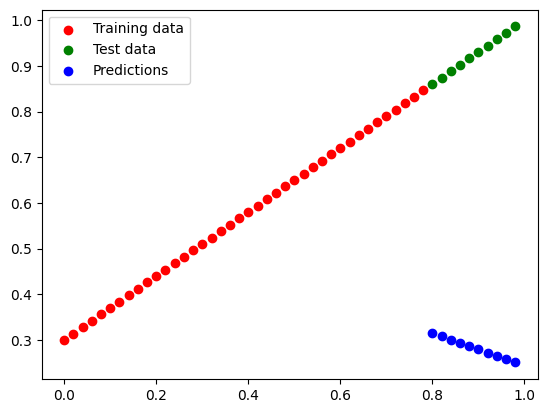

In [12]:
plot_graph(predictions=y_preds)

## Train model

- one way to measure how poor are the model predictions are, we use loss functions/ cost functions/ criterion.

In [13]:
# loss function
loss_fn= nn.L1Loss()

# optimizer
optimizer= torch.optim.SGD(params= model_0.parameters(), lr= 0.01)   # lr -> learning rate (hyper parameter)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### Building a training loop (and a testing loop)

In [14]:
epochs= 1000   # epoch is one loop through the data (hyperparameter)

epoch_count= []
loss_values= []
test_loss_values= []

# Training
# 0. loop through the data
for epoch in range(epochs):
  model_0.train()   # train model sets all parameters that require gradients to require gradients

  # 1. forward pass
  y_pred= model_0(X_train)

  # 2. Loss function (MAE -> mean absolute error)
  loss= loss_fn(y_pred, y_train)    # loss(input, target)
  # print(f"Loss: {loss}")

  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. Backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step()    # by default how the optimizer changes will accumulate through the loop, so we've to zero them in step 3 for the next iteration



  # Testing
  model_0.eval()    # turns off default settings in the model not needed for evaluation/ testing like dropout, batch norm layers
  with torch.inference_mode():    # turns of gradient tracking and more
    # 1. forward pass
    test_pred= model_0(X_test)

    # 2. Calculate loss
    test_loss= loss_fn(test_pred, y_test)




  if epoch% 10== 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
    print(model_0.state_dict())  # print state_dict

Epoch: 0 | Loss: 0.2260170727968216 | Test loss: 0.634822428226471
OrderedDict({'weights': tensor([-0.3540]), 'bias': tensor([0.6032])})
Epoch: 10 | Loss: 0.2132083624601364 | Test loss: 0.5882585644721985
OrderedDict({'weights': tensor([-0.3264]), 'bias': tensor([0.6252])})
Epoch: 20 | Loss: 0.20385579764842987 | Test loss: 0.5493677258491516
OrderedDict({'weights': tensor([-0.3007]), 'bias': tensor([0.6412])})
Epoch: 30 | Loss: 0.19708040356636047 | Test loss: 0.5182749629020691
OrderedDict({'weights': tensor([-0.2770]), 'bias': tensor([0.6512])})
Epoch: 40 | Loss: 0.1917887181043625 | Test loss: 0.49312353134155273
OrderedDict({'weights': tensor([-0.2549]), 'bias': tensor([0.6567])})
Epoch: 50 | Loss: 0.1871875673532486 | Test loss: 0.47197794914245605
OrderedDict({'weights': tensor([-0.2339]), 'bias': tensor([0.6592])})
Epoch: 60 | Loss: 0.1831875741481781 | Test loss: 0.4541779160499573
OrderedDict({'weights': tensor([-0.2139]), 'bias': tensor([0.6592])})
Epoch: 70 | Loss: 0.17924

In [15]:
with torch.inference_mode():
  y_preds_new= model_0(X_test)

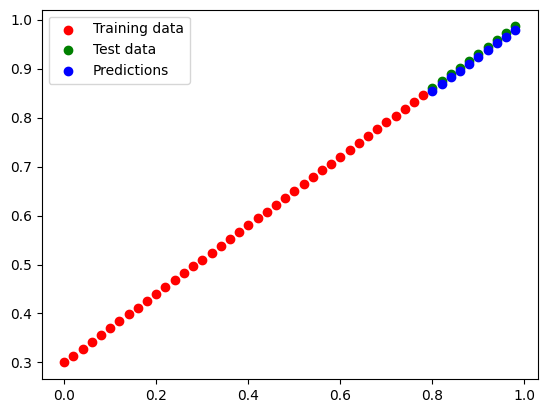

In [16]:
plot_graph(predictions=y_preds_new)

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6943])), ('bias', tensor([0.2987]))])

/tmp/ipython-input-1250224745.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), c='r', label="Train Loss")


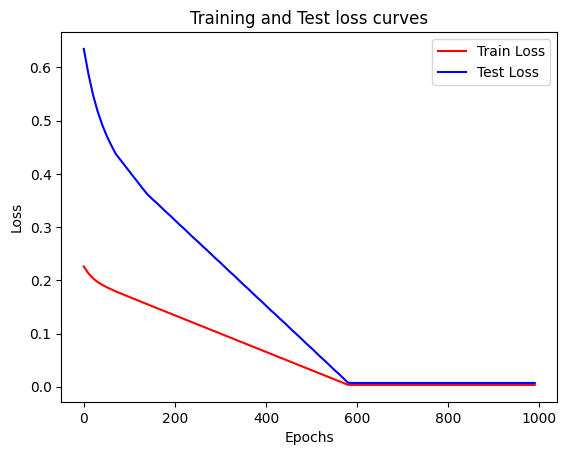

In [18]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), c='r', label="Train Loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), c='b', label= "Test Loss")
plt.title("Training and Test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## Saving the model

- `torch.save()`  -> saves pytorch object in python's pickle format
- `torch.load()`  -> load a saved pytorch object
- `torch.nn.Module.load_state_dict()`  -> load a model's saved state dictionary



In [28]:
# saving the model
from pathlib import Path

# 1. create a directory (called models)
MODEL_PATH= Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok= True)

# 2. Create model save path
MODEL_NAME= "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH= MODEL_PATH / MODEL_NAME

# 3. Save the model state dict (recommended option)
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj= model_0.state_dict(), f= MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model.pth


In [29]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2101 Sep 23 12:54 01_pytorch_workflow_model.pth


### Loading the model

Since we saved the `state_dict()` instead of the entire model, we'll create a new instance of the model class and load saved `state_dict()` into that.

In [30]:
# Instantiate a new class
loaded_model_0= LinearRegressionModel()

# Load the saved model state_dict (will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [24]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([-0.6968])), ('bias', tensor([-0.5242]))])

In [31]:
## Make predictions with the loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_pred= loaded_model_0(X_test)
loaded_model_pred

tensor([[0.8542],
        [0.8681],
        [0.8820],
        [0.8959],
        [0.9097],
        [0.9236],
        [0.9375],
        [0.9514],
        [0.9653],
        [0.9792]])

In [34]:
loaded_model_0.eval()
with torch.inference_mode():
  y_preds= loaded_model_0(X_test)
y_preds

tensor([[0.8542],
        [0.8681],
        [0.8820],
        [0.8959],
        [0.9097],
        [0.9236],
        [0.9375],
        [0.9514],
        [0.9653],
        [0.9792]])

In [35]:
y_preds == loaded_model_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])